# Sweet Spot Holiday Index
---

## Overview

This notebook builds a holiday score from **0 to 1** where higher means better for travellers seeking a balanced destination across:

- **Environment** (comfortable weather)
- **Economy** (affordability without extreme outliers)
- **Risk** (lower disaster exposure)

The scoring is designed to reduce artificial clustering at `1.0` by using tighter target ranges and smooth desirability functions.

---

## Indicator Specs

| Pillar | Indicator | Scoring Type | Preferred Zone / Direction | Bounds |
|---|---|---|---|---|
| Environment | `temperature_celsius` | target | 23 - 26 degC | worst: 8 to 38 |
| Environment | `wind_kph` | target | 7 - 14 kph | worst: 0 to 40 |
| Environment | `uv_index` | target | 4.0 - 5.5 | worst: 0 to 11 |
| Environment | `condition_score` | high | higher is better | 0 to 5 |
| Economy | `Mid_range_meal_pp` | target | $8 - $28 | worst: $1 to $120 |
| Economy | `One_way_local_transport_ticket` | target | $0.40 - $1.80 | worst: $0 to $7 |
| Economy | `Apartment` | target | $250 - $900 /mo | worst: $80 to $5,500 |
| Risk | `Disaster_Count` | low | lower is better | 0 to 15 |
| Risk | `Median_Severity` | low | lower is better | 0 to 1 |
| Risk | `Unique_Days_Under_Threat` | low | lower is better | 0 to 365 |

## Weights

| Pillar | Weight |
|---|---|
| Economy | 35 % |
| Environment | 40 % |
| Risk | 25 % |

---

In [7]:
import pandas as pd

# 1) Load combined holiday data
input_path = "../Combining_Code_And_Results/Combined_Holiday.csv"
df = pd.read_csv(input_path)

print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
display(df.head())

Rows: 170, Columns: 13


,country,Mid_range_meal_pp,One_way_local_transport_ticket,Apartment,temperature_celsius,wind_kph,uv_index,condition_text,condition_category,condition_score,Disaster_Count,Median_Severity,Unique_Days_Under_Threat
0,Afghanistan,3.41,0.22,79.90,18.754247,10.340000,4.694795,sunny,Clear,5,6.0,0.50,22.0
1,Albania,12.48,0.43,186.79,21.625479,9.776438,4.181096,sunny,Clear,5,1.0,0.00,7.0
2,Algeria,6.66,0.21,143.88,22.275068,14.090685,3.846849,partly cloudy,Partly Cloudy,4,5.0,0.25,8.0
3,Andorra,20.17,1.90,811.73,10.402192,9.050137,2.798630,sunny,Clear,5,0.0,0.00,0.0
4,Angola,32.12,0.59,220.39,27.371233,11.057808,6.942192,partly cloudy,Partly Cloudy,4,2.0,1.00,11.0


## Scoring Design

To avoid score saturation, this version uses **desirability functions** instead of a wide flat trapezoid:

- `target_score`: best around a central comfort zone; falls linearly toward both low/high worst bounds
- `low_is_better_score`: for risk metrics where lower values are better
- `high_is_better_score`: for metrics where higher values are better

This means far fewer exact `1.0` values and better separation between countries.

In [8]:
import numpy as np

# 2) Desirability scoring functions (all scores in [0, 1])
def target_score(series, ideal_low, ideal_high, worst_low, worst_high):
    """
    Highest score at the center of the ideal band, then decreases linearly
    toward worst bounds on either side.
    """
    s = pd.to_numeric(series, errors="coerce")
    center = (ideal_low + ideal_high) / 2

    score = pd.Series(0.0, index=s.index, dtype=float)

    left_span = max(center - worst_low, 1e-9)
    right_span = max(worst_high - center, 1e-9)

    left_mask = s <= center
    right_mask = s > center

    score[left_mask] = 1 - ((center - s[left_mask]) / left_span)
    score[right_mask] = 1 - ((s[right_mask] - center) / right_span)

    score[s.isna()] = 0.0
    return score.clip(0.0, 1.0)


def low_is_better_score(series, best, worst):
    """ scores where lower values are better."""
    s = pd.to_numeric(series, errors="coerce")
    span = max(worst - best, 1e-9)
    score = 1 - ((s - best) / span)
    score[s.isna()] = 0.0
    return score.clip(0.0, 1.0)


def high_is_better_score(series, worst, best):
    """ score where higher values are better."""
    s = pd.to_numeric(series, errors="coerce")
    span = max(best - worst, 1e-9)
    score = (s - worst) / span
    score[s.isna()] = 0.0
    return score.clip(0.0, 1.0)


# 3) Parameterized specs for each indicator
#    type:
#    - target: best around a middle band
#    - low: lower is better
#    - high: higher is better
specs = {
    # Environment
    "temperature_celsius": {"type": "target", "ideal_low": 23.0, "ideal_high": 26.0, "worst_low": 8.0, "worst_high": 38.0},
    "wind_kph": {"type": "target", "ideal_low": 7.0, "ideal_high": 14.0, "worst_low": 0.0, "worst_high": 40.0},
    "uv_index": {"type": "target", "ideal_low": 4.0, "ideal_high": 5.5, "worst_low": 0.0, "worst_high": 11.0},
    "condition_score": {"type": "high", "worst": 0.0, "best": 5.0},

    # Economy (too expensive and unrealistically cheap are both less ideal)
    "Mid_range_meal_pp": {"type": "target", "ideal_low": 8.0, "ideal_high": 28.0, "worst_low": 1.0, "worst_high": 120.0},
    "One_way_local_transport_ticket": {"type": "target", "ideal_low": 0.40, "ideal_high": 1.80, "worst_low": 0.00, "worst_high": 7.0},
    "Apartment": {"type": "target", "ideal_low": 250.0, "ideal_high": 900.0, "worst_low": 80.0, "worst_high": 5500.0},

    # Risk
    "Disaster_Count": {"type": "low", "best": 0.0, "worst": 15.0},
    "Median_Severity": {"type": "low", "best": 0.0, "worst": 1.0},
    "Unique_Days_Under_Threat": {"type": "low", "best": 0.0, "worst": 365.0},
}


# Apply scoring
available = [c for c in specs if c in df.columns]
missing = [c for c in specs if c not in df.columns]

for col in available:
    cfg = specs[col]
    if cfg["type"] == "target":
        df[f"score_{col}"] = target_score(
            df[col],
            cfg["ideal_low"],
            cfg["ideal_high"],
            cfg["worst_low"],
            cfg["worst_high"],
        )
    elif cfg["type"] == "low":
        df[f"score_{col}"] = low_is_better_score(df[col], cfg["best"], cfg["worst"])
    elif cfg["type"] == "high":
        df[f"score_{col}"] = high_is_better_score(df[col], cfg["worst"], cfg["best"])

print(f"Desirability scores created for {len(available)} indicators.")
if missing:
    print("Skipped (not in dataset):", missing)


Desirability scores created for 10 indicators.


## Build Pillar Scores and Final Sweet Spot Index

Pillar scores use a **geometric mean** of their indicator scores, which penalizes imbalanced countries (one weak metric can no longer be hidden by others).

The final index is a weighted combination: **Economy 35 % · Environment 40 % · Risk 25 %**.

In [9]:
# 4) Build pillar scores and final Sweet Spot Holiday Index

economy_cols = ["score_Mid_range_meal_pp", "score_One_way_local_transport_ticket", "score_Apartment"]
environment_cols = ["score_temperature_celsius", "score_wind_kph", "score_uv_index", "score_condition_score"]
risk_cols = ["score_Disaster_Count", "score_Median_Severity", "score_Unique_Days_Under_Threat"]


def mean_of_existing(frame, cols):
    cols = [c for c in cols if c in frame.columns]
    if not cols:
        return pd.Series(0.0, index=frame.index)
    return frame[cols].mean(axis=1)


def geometric_mean_of_existing(frame, cols, eps=1e-6):
    """Geometric mean penalizes weak indicators more than arithmetic mean."""
    cols = [c for c in cols if c in frame.columns]
    if not cols:
        return pd.Series(0.0, index=frame.index)
    clipped = frame[cols].clip(lower=eps)
    return np.exp(np.log(clipped).mean(axis=1))


# Pillar scores: geometric mean to avoid one perfect metric masking weaker ones
# Pillars with a single metric still behave naturally.
df["Economy_Score"] = geometric_mean_of_existing(df, economy_cols)
df["Environment_Score"] = geometric_mean_of_existing(df, environment_cols)
df["Risk_Score"] = geometric_mean_of_existing(df, risk_cols)

weights = {"Economy_Score": 0.35, "Environment_Score": 0.40, "Risk_Score": 0.25}
df["Holiday_Index"] = sum(df[col] * w for col, w in weights.items())

display(df[["country", "Economy_Score", "Environment_Score", "Risk_Score", "Holiday_Index"]].head())

,country,Economy_Score,Environment_Score,Risk_Score,Holiday_Index
0,Afghanistan,0.003049,0.892458,0.655704,0.521976
1,Albania,0.384738,0.907014,0.970977,0.740208
2,Algeria,0.201675,0.837640,0.787859,0.602607
3,Andorra,0.930383,0.521447,1.000000,0.784213
4,Angola,0.507957,0.795866,0.009437,0.498491


## Country Rankings

The top 20 sweet spot holiday destinations are as follows:

In [10]:
# 5) Rank countries and show top 20

top_20 = (
    df.sort_values("Holiday_Index", ascending=False)
      .loc[:, [
          "country",
          "Holiday_Index",
          "Economy_Score",
          "Environment_Score",
          "Risk_Score",
          "temperature_celsius",
          "Mid_range_meal_pp",
      ]]
      .head(20)
      .reset_index(drop=True)
)

display(top_20)

,country,Holiday_Index,Economy_Score,Environment_Score,Risk_Score,temperature_celsius,Mid_range_meal_pp
0,Vatican City,0.924637,0.912650,0.888023,1.000000,20.411233,15.58
1,Cyprus,0.916913,0.938362,0.864355,0.970977,25.484384,24.67
2,Israel,0.909889,0.866349,0.891666,1.000000,24.111781,39.78
3,Malta,0.880417,0.890468,0.815023,0.970977,22.810411,33.70
4,San Marino,0.878074,0.885119,0.795706,1.000000,17.841370,27.18
5,Kuwait,0.867788,0.965410,0.699737,1.000000,31.823288,21.14
6,Greece,0.845399,0.898378,0.879446,0.716752,22.914521,20.26
7,Bahrain,0.839642,0.859980,0.721621,1.000000,29.943562,21.66
8,Trinidad And Tobago,0.836631,0.794848,0.771084,1.000000,25.857808,34.05
9,Portugal,0.834285,0.953036,0.716405,0.856640,18.051781,17.58


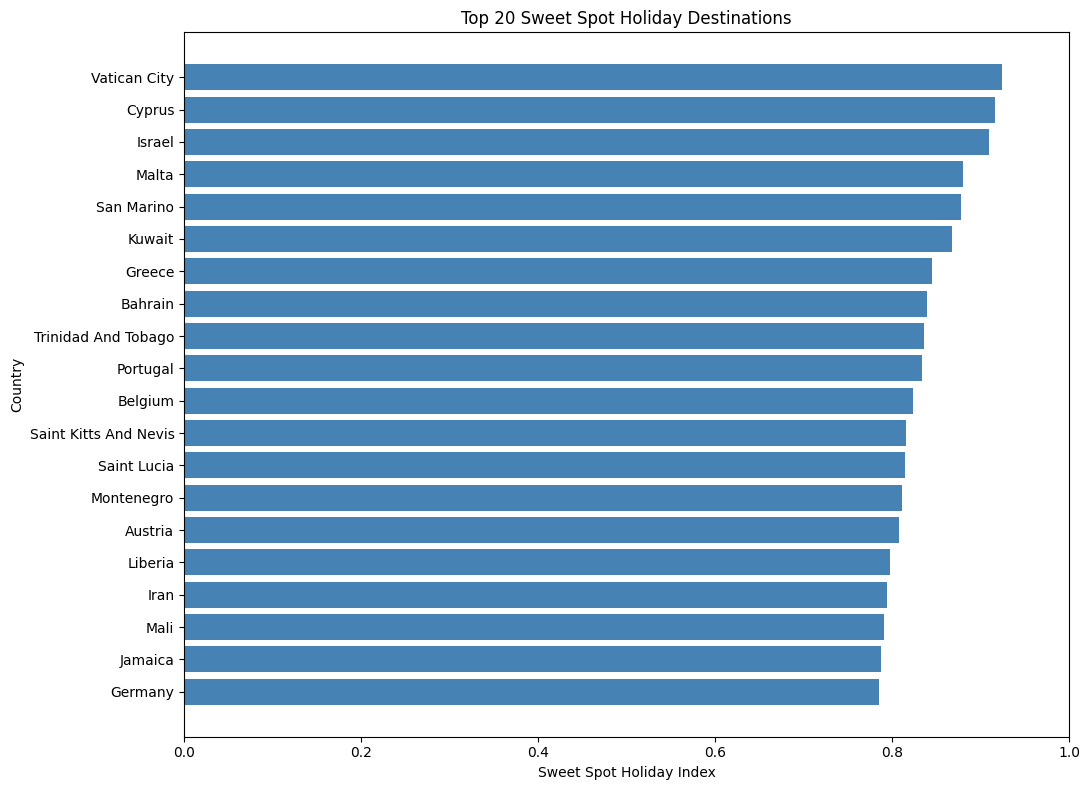

In [11]:
# 6) Graph top 20 countries by Holiday Index
import matplotlib.pyplot as plt

plot_df = top_20.sort_values("Holiday_Index", ascending=True)

plt.figure(figsize=(11, 8))
plt.barh(plot_df["country"], plot_df["Holiday_Index"], color="steelblue")
plt.xlabel("Sweet Spot Holiday Index")
plt.ylabel("Country")
plt.title("Top 20 Sweet Spot Holiday Destinations")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()